# DTATo20. deeptrack.optical.optics

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/3-advanced-topics/DTATo20_optics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

This advanced tutorial introduces the module [deeptrack.optical.optics](../../deeptrack/optical/optics.py).

In [2]:
import matplotlib.pyplot as plt

## 1. What is an Optical Device?

Optical devices are implementations of the abstract class `Features` (see also [DTAT301_features](DTAT301_features.ipynb)) that image their input through some optical setup. They create a discretized 3-dimensional representation of the input and calculate the corresponding field intensity at the camera. 

The syntax to call an optical device on a feature series `F` is `optics(F)`.

## 2. Using Fluorescence

The feature `Fluorescence` takes scatterers with the property `intensity`, which represents the intensity of the light emitted by each voxel. 

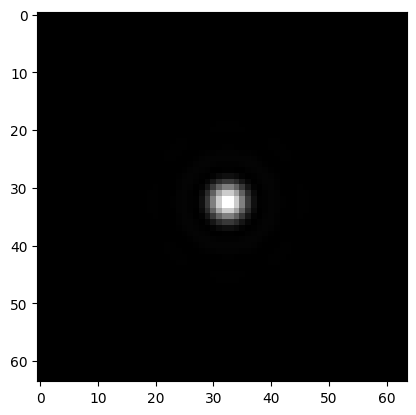

In [3]:
from deeptrack.optical.optics import Fluorescence
from deeptrack.scatterers import PointParticle

optics = Fluorescence(
    NA=0.7,  # Numerical aperture
    wavelength=660e-9,  # Wavelength of the emitted light
    resolution=1e-6,  # Pixel size of the camera, also determines z-resolution
    magnification=10,  # Magnification of the optical aperature
    refractive_index_medium=1.33,  # Refractive index of the medium
    upscale=2,  # Upscales the pupil function for accuracy
    padding=(10, 10, 10, 10),  # Pads image with this number of pixels,
                               # (left, right, up, down)
    output_region=(0, 0, 64, 64),  # Extracts a part of the output image,
                                   # (x, y, width, height)
    aberration=None,  # Option to add aberration
)

scatterer = PointParticle(
    intensity=100,  # Squared magnitude of the field
    position_unit="pixel",  # Units of position (default meter)
    position=(32, 32),  # Position of the particle
)

imaged_scatterer = optics(scatterer)

imaged_scatterer.plot(cmap="gray")
plt.show()

Using the syntax `optics(F)` to call an optical device on a feature series F, the properties of the optical device are accessible by `optics` ...

In [4]:
optics.NA()

0.7

...  while the feature is still accessible by `F`.

In [5]:
scatterer.position()

(32, 32)

## 3. Using Brightfield

The feature `Brightfield` coherently illuminates scatterers with the property `refractive_index`, which  represents the refractive_index of the scatterer.

/Users/giovannivolpe/Documents/GitHub/DeepTrack2/deeptrack/optical/optics.py:1878: UserWarning: Brightfield imaging from ScatteredVolume assumes a weak-phase / projection approximation. Use ScatteredField for physically accurate brightfield simulations.
  warnings.warn(


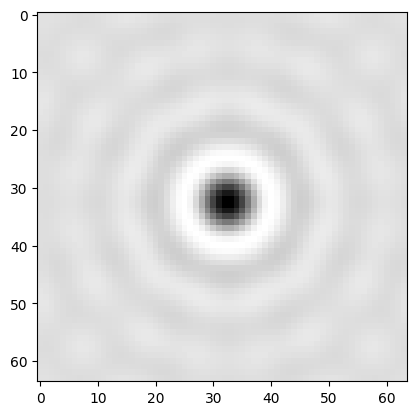

In [6]:
from deeptrack.optical.optics import Brightfield

optics = Brightfield(
    NA=0.7,  # Numerical aperture
    wavelength=660e-9,  # Wavelength of the illumination light
    resolution=1e-6,  # Pixel size of the camera
    magnification=10,  # Magnification of the optical aperature
    refractive_index_medium=1.33,  # Refractive index of the medium
    upscale=2,  # Upscales the pupil function for accuracy
    output_region=(0, 0, 64, 64),  # Extracts a part of the output image
    padding=(10, 10, 10, 10),  # Pads image with this number of pixels,
                               # (left, right, up, down)
    aberration=None,  # Option to add aberration
)

scatterer = PointParticle(
    refractive_index=1.45 + 0.1j,
    position_unit="pixel",
    position=(32, 32),
)

imaged_scatterer = optics(scatterer)

imaged_scatterer.plot(cmap="gray")
plt.show()

The illuminating light can be further tuned by setting the property `illumination`. Here, for example, you add a background gradient using the feature `IlluminationGradient`.

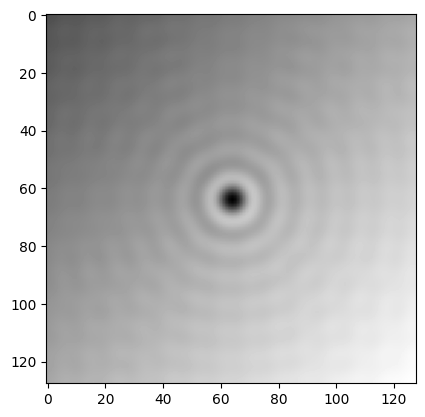

In [7]:
from deeptrack.optical.optics import IlluminationGradient

illumination_gradient = IlluminationGradient(
    gradient=(2e-5, 2e-5),  # Adds a field with the corresponing gradient
)

optics = Brightfield(
    NA=0.7,
    wavelength=660e-9,
    resolution=1e-6,
    magnification=10,
    refractive_index_medium=1.33,
    upscale=1,
    output_region=(0, 0, 128, 128),
    padding=(50, 50, 50, 50),
    aberration=None,
    illumination=illumination_gradient,  # Field illuminating the sample
)

scatterer = PointParticle(
    refractive_index=1.45 + 0.1j,
    position_unit="pixel",
    position=(64, 64),
)

imaged_scatterer = optics(scatterer)

imaged_scatterer.plot(cmap="gray")
plt.show()

## 4. Using Other Imaging Modalities

In addition to fluorescence and brightfield microscopy, other imaging modalities are available, including holography, darkfield, and interferometric scattering (ISCAT) microscopy. These can be used in an analogous manner, see also [DTGS106_particle_image_modalities](../1-getting-started/DTGS106_particle_image_modalities.ipynb).